<a href="https://colab.research.google.com/github/CYkir/river-trash-research/blob/main/segmentasi%20area%20tutupan%20sampah%20-%20Mask%20R-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Tue Jun 16 16:51:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q opencv-python matplotlib pandas tqdm pycocotools

!python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 26.8 MB/s eta 0:00:00


In [3]:
import torch
import detectron2

print("Torch:", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())
print("Detectron2 berhasil diimport")

Torch: 2.11.0+cu128
CUDA tersedia: True
Detectron2 berhasil diimport


In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset_sampah.zip to dataset_sampah.zip


In [5]:
!mkdir -p /content/dataset_sampah
!unzip -q dataset_sampah.zip -d /content/dataset_sampah

!find /content/dataset_sampah -maxdepth 2 -type f | head

/content/dataset_sampah/valid/B_train_015_jpeg.rf.50d26012005adc589dbb0e07f79801fa.jpg
/content/dataset_sampah/valid/IMG_4969_JPG.rf.8197bce526beed85cffbcb993818d437.jpg
/content/dataset_sampah/valid/A_train_001_jpeg.rf.67ac1ab49905aa441bf01f00eababde8.jpg
/content/dataset_sampah/valid/IMG_5037_JPG.rf.a4191072cd4b096453ca033f002d324c.jpg
/content/dataset_sampah/valid/A_train_011_jpeg.rf.01097d3412f9d6ad5ea8a486851cbf9c.jpg
/content/dataset_sampah/valid/IMG_5044_JPG.rf.b4a4e74c783444ad8a45a83383a8fee4.jpg
/content/dataset_sampah/valid/IMG_4902_JPG.rf.533a708daaba3246c4a336bef73f0a7a.jpg
/content/dataset_sampah/valid/IMG_5060_JPG.rf.f125ad8d63051297e40e14a51c1d2d8e.jpg
/content/dataset_sampah/valid/IMG_4897_JPG.rf.d386273baa6c0a9a3f07f8863e52d281.jpg
/content/dataset_sampah/valid/IMG_5045_JPG.rf.e99c5c3364f2f72624587d63c912ff4c.jpg


In [6]:
!ls -R /content/dataset_sampah | head -80

/content/dataset_sampah:
test
train
valid

/content/dataset_sampah/test:
_annotations.coco.json
A_train_004_jpeg.rf.4763f763402034466477cf08613a0a45.jpg
B_train_003_jpeg.rf.a3fb131e70c715667af44c051deb3148.jpg
B_train_005_jpeg.rf.04bc2635a42e708e2cb2838a620ec0c6.jpg
B_train_023_jpeg.rf.4fcb5f7d68cf84b4649e7b432926ce8f.jpg
B_train_025_jpeg.rf.8ffa3ad203bc892c2edb92c6e7b2a912.jpg
IMG_4857_JPG.rf.a73adb6cc498bcff4768abe65d69dd67.jpg
IMG_4876_JPG.rf.bac4422e06f670eef0ce2e69fe5f7ab6.jpg
IMG_4926_JPG.rf.c590fd6900a58385ac968bf34e2fa744.jpg
IMG_4941_JPG.rf.710d39d898cde0a05abd69dd42b50272.jpg
IMG_4948_JPG.rf.4a25936faf84a9f7ea2bd885469a3971.jpg
IMG_4966_JPG.rf.9a2f16d87067ea4c065c603ec994719c.jpg
IMG_4994_JPG.rf.cb9b971459b53746c20f837e533c49cd.jpg
IMG_5002_JPG.rf.9b468399387d84d730a3041503018dbe.jpg
IMG_5041_JPG.rf.4de4c328768c59345ffeeb7c0b8db3d5.jpg

/content/dataset_sampah/train:
_annotations.coco.json
A_train_002_jpeg.rf.1e33de96722105bf9e5e76785231a25a.jpg
A_train_003_jpeg.rf.9b60ccbb66

In [7]:
# cek isi dataset
import json
import os

DATASET_DIR = "/content/dataset_sampah"

for split in ["train", "valid", "test"]:
    json_path = os.path.join(DATASET_DIR, split, "_annotations.coco.json")

    with open(json_path, "r") as f:
        data = json.load(f)

    print("\nSPLIT:", split)
    print("Jumlah images:", len(data.get("images", [])))
    print("Jumlah annotations:", len(data.get("annotations", [])))
    print("Categories:", data.get("categories", []))


SPLIT: train
Jumlah images: 107
Jumlah annotations: 282
Categories: [{'id': 1, 'name': 'sampah', 'supercategory': 'none'}]

SPLIT: valid
Jumlah images: 26
Jumlah annotations: 78
Categories: [{'id': 1, 'name': 'sampah', 'supercategory': 'none'}]

SPLIT: test
Jumlah images: 14
Jumlah annotations: 63
Categories: [{'id': 1, 'name': 'sampah', 'supercategory': 'none'}]


In [8]:
# Register Dataset ke Detectron2

import os
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog

DATASET_DIR = "/content/dataset_sampah"

TRAIN_JSON = os.path.join(DATASET_DIR, "train", "_annotations.coco.json")
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train")

VALID_JSON = os.path.join(DATASET_DIR, "valid", "_annotations.coco.json")
VALID_IMG_DIR = os.path.join(DATASET_DIR, "valid")

TEST_JSON = os.path.join(DATASET_DIR, "test", "_annotations.coco.json")
TEST_IMG_DIR = os.path.join(DATASET_DIR, "test")

# Hapus register lama kalau cell dijalankan ulang
for d in ["sampah_train", "sampah_valid", "sampah_test"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
        MetadataCatalog.remove(d)

register_coco_instances("sampah_train", {}, TRAIN_JSON, TRAIN_IMG_DIR)
register_coco_instances("sampah_valid", {}, VALID_JSON, VALID_IMG_DIR)
register_coco_instances("sampah_test", {}, TEST_JSON, TEST_IMG_DIR)

metadata = MetadataCatalog.get("sampah_train")
metadata.thing_classes = ["sampah"]

print("Dataset berhasil diregister")
print("Class:", metadata.thing_classes)

Dataset berhasil diregister
Class: ['sampah']


Jumlah data train: 107


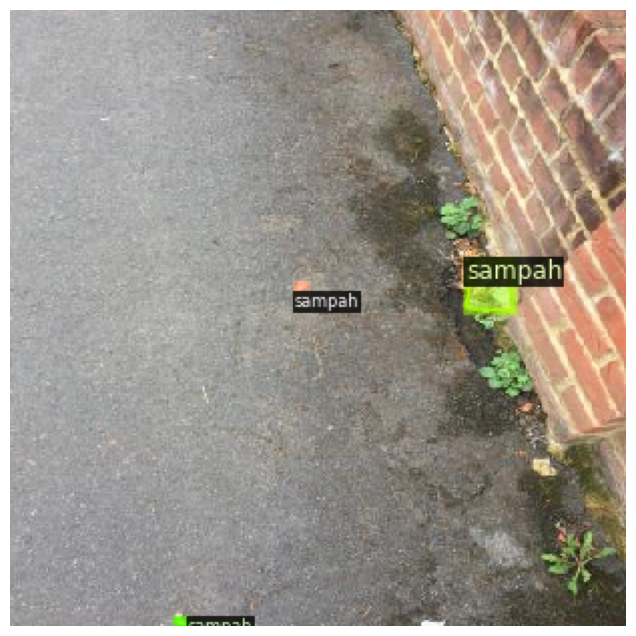

In [9]:
# Cek Visual Label Dataset

import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.data import DatasetCatalog, MetadataCatalog

dataset_dicts = DatasetCatalog.get("sampah_train")
metadata = MetadataCatalog.get("sampah_train")

print("Jumlah data train:", len(dataset_dicts))

sample = random.choice(dataset_dicts)
img = cv2.imread(sample["file_name"])

v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.8)
out = v.draw_dataset_dict(sample)

plt.figure(figsize=(10, 8))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

In [10]:
# Training Mask R-CNN -> Mask R-CNN R50-FPN

import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

OUTPUT_DIR = "/content/output_maskrcnn_sampah"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.DATASETS.TRAIN = ("sampah_train",)
cfg.DATASETS.TEST = ("sampah_valid",)

cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

# Karena class hanya 1: sampah
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

# Setting ringan untuk Colab
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 1000
cfg.SOLVER.STEPS = []

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

cfg.OUTPUT_DIR = OUTPUT_DIR

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[06/16 17:04:14 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:00, 204MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[06/16 17:04:15 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0616 17:04:18.301000 422 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[06/16 17:04:25 d2.utils.events]:  eta: 0:05:15  iter: 19  total_loss: 2.033  loss_cls: 0.6488  loss_box_reg: 0.5081  loss_mask: 0.6925  loss_rpn_cls: 0.09815  loss_rpn_loc: 0.02063    time: 0.3193  last_time: 0.3452  data_time: 0.0128  last_data_time: 0.0067   lr: 4.9953e-06  max_mem: 1799M
[06/16 17:04:35 d2.utils.events]:  eta: 0:05:07  iter: 39  total_loss: 2.082  loss_cls: 0.603  loss_box_reg: 0.6131  loss_mask: 0.6845  loss_rpn_cls: 0.08116  loss_rpn_loc: 0.0161    time: 0.3197  last_time: 0.3330  data_time: 0.0062  last_data_time: 0.0087   lr: 9.9902e-06  max_mem: 1804M
[06/16 17:04:41 d2.utils.events]:  eta: 0:05:00  iter: 59  total_loss: 2  loss_cls: 0.5257  loss_box_reg: 0.6132  loss_mask: 0.6696  loss_rpn_cls: 0.06694  loss_rpn_loc: 0.01693    time: 0.3190  last_time: 0.2786  data_time: 0.0066  last_data_time: 0.0050   lr: 1.4985e-05  max_mem: 1804M
[06/16 17:04:48 d2.utils.events]:  eta: 0:04:51  iter: 79  total_loss: 1.831  loss_cls: 0.4414  loss_box_reg: 0.6121  loss_mask

In [11]:
# Evaluasi Model pada Data Test Roboflow

from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

evaluator = COCOEvaluator("sampah_test", output_dir=cfg.OUTPUT_DIR)
test_loader = build_detection_test_loader(cfg, "sampah_test")

eval_results = inference_on_dataset(trainer.model, test_loader, evaluator)
eval_results

[06/16 17:11:09 d2.data.datasets.coco]: Loaded 14 images in COCO format from /content/dataset_sampah/test/_annotations.coco.json
[06/16 17:11:09 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
|   sampah   | 63           |
|            |              |
[06/16 17:11:09 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[06/16 17:11:09 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[06/16 17:11:09 d2.data.common]: Serializing 14 elements to byte tensors and concatenating them all ...
[06/16 17:11:09 d2.data.common]: Serialized dataset takes 0.03 MiB
[06/16 17:11:09 d2.evaluation.evaluator]: Start inference on 14 batches
[06/16 17:11:11 d2.evaluation.evaluator]: Inference done 11/14. Dataloading: 0.0028 s/iter. Inference: 0.0978 s/iter. Eval: 0.012

OrderedDict([('bbox',
              {'AP': 18.269736519786907,
               'AP50': 28.02732790635408,
               'AP75': 18.883159278660784,
               'APs': 7.458961017359789,
               'APm': 22.455058012420547,
               'APl': 63.082508250825086}),
             ('segm',
              {'AP': 17.887881972875444,
               'AP50': 28.743240608191282,
               'AP75': 17.461028711566808,
               'APs': 6.224818202366557,
               'APm': 20.99184576051986,
               'APl': 67.50307383679545})])

TESTING

In [12]:
from google.colab import files
uploaded = files.upload()

Saving testing_lapangan.zip to testing_lapangan.zip


In [13]:
!mkdir -p /content/testing_lapangan_data
!unzip -q testing_lapangan.zip -d /content/testing_lapangan_data

!find /content/testing_lapangan_data -maxdepth 3 -type f | head

/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_008.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_007.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_002.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_001.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_006.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_005.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_004.jpeg
/content/testing_lapangan_data/testing_lapangan/titik_2/B_test_003.jpeg
/content/testing_lapangan_data/testing_lapangan/tiitk_1/A_test_006.jpeg
/content/testing_lapangan_data/testing_lapangan/tiitk_1/A_test_008.jpeg


In [15]:
!apt-get install -y tree
!tree /content/testing_lapangan_data -L 3

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (254 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/testing_lapangan_data
└── testing_lapangan
    ├── tiitk_1
    │   ├── A_test_001.jpeg
    │   ├── A_test_002.jpeg
    │   ├── A_test_003.jpeg
    │   ├── A_test_004.jpeg
    │   ├── A_test_005.jpeg
    │   ├── A_test_006.jpeg
    │   ├── A_test_007.jpeg
    │   └── A_test_008.j

In [16]:
# Testing Foto Lapangan + Hitung Area Sampah

import os
import cv2
import numpy as np
import pandas as pd

from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

# Load model hasil training
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

metadata = MetadataCatalog.get("sampah_train")
metadata.thing_classes = ["sampah"]

# Sesuaikan kalau hasil unzip beda
TESTING_ROOT = "/content/testing_lapangan_data/testing_lapangan"
HASIL_ROOT = "/content/hasil_segmentasi"

os.makedirs(HASIL_ROOT, exist_ok=True)

def kategori_pencemaran(persen):
    if persen <= 20:
        return "Rendah"
    elif persen <= 50:
        return "Sedang"
    else:
        return "Tinggi"

all_results = []

for lokasi in os.listdir(TESTING_ROOT):
    lokasi_path = os.path.join(TESTING_ROOT, lokasi)

    if not os.path.isdir(lokasi_path):
        continue

    output_lokasi = os.path.join(HASIL_ROOT, lokasi)
    os.makedirs(output_lokasi, exist_ok=True)

    for filename in os.listdir(lokasi_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(lokasi_path, filename)
        img = cv2.imread(image_path)

        if img is None:
            print("Gagal membaca:", image_path)
            continue

        outputs = predictor(img)
        instances = outputs["instances"].to("cpu")

        if instances.has("pred_masks"):
            masks = instances.pred_masks.numpy()
        else:
            masks = []

        area_sampah = 0

        for mask in masks:
            area_sampah += int(np.sum(mask))

        tinggi, lebar = img.shape[:2]
        total_area = tinggi * lebar

        persentase_tutupan = (area_sampah / total_area) * 100 if total_area > 0 else 0
        kategori = kategori_pencemaran(persentase_tutupan)

        v = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=1.0,
            instance_mode=ColorMode.IMAGE_BW
        )

        out = v.draw_instance_predictions(instances)
        hasil_img = out.get_image()[:, :, ::-1]

        save_path = os.path.join(output_lokasi, f"hasil_{filename}")
        cv2.imwrite(save_path, hasil_img)

        all_results.append({
            "lokasi": lokasi,
            "gambar": filename,
            "jumlah_objek_terdeteksi": len(masks),
            "area_sampah_pixel": area_sampah,
            "total_area_pixel": total_area,
            "persentase_tutupan_sampah": round(persentase_tutupan, 2),
            "kategori_pencemaran_visual": kategori,
            "path_hasil_segmentasi": save_path
        })

df_results = pd.DataFrame(all_results)

csv_path = "/content/hasil_segmentasi/hasil_pengujian.csv"
df_results.to_csv(csv_path, index=False)

df_results

[06/16 17:14:42 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output_maskrcnn_sampah/model_final.pth ...


,lokasi,gambar,jumlah_objek_terdeteksi,area_sampah_pixel,total_area_pixel,persentase_tutupan_sampah,kategori_pencemaran_visual,path_hasil_segmentasi
0,titik_2,B_test_008.jpeg,12,295163,1638400,18.02,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
1,titik_2,B_test_007.jpeg,5,102428,1638400,6.25,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
2,titik_2,B_test_002.jpeg,7,209577,1638400,12.79,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
3,titik_2,B_test_001.jpeg,8,225377,1638400,13.76,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
4,titik_2,B_test_006.jpeg,7,114646,1638400,7.00,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
5,titik_2,B_test_005.jpeg,8,211683,1638400,12.92,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
6,titik_2,B_test_004.jpeg,11,277303,1638400,16.93,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
7,titik_2,B_test_003.jpeg,8,143187,1638400,8.74,Rendah,/content/hasil_segmentasi/titik_2/hasil_B_test...
8,tiitk_1,A_test_006.jpeg,8,121733,1003408,12.13,Rendah,/content/hasil_segmentasi/tiitk_1/hasil_A_test...
9,tiitk_1,A_test_008.jpeg,9,168038,1003408,16.75,Rendah,/content/hasil_segmentasi/tiitk_1/hasil_A_test...


In [17]:
# ringkasan perlokasi

summary = (
    df_results
    .groupby("lokasi")
    .agg(
        jumlah_gambar=("gambar", "count"),
        rata_rata_tutupan=("persentase_tutupan_sampah", "mean"),
        min_tutupan=("persentase_tutupan_sampah", "min"),
        max_tutupan=("persentase_tutupan_sampah", "max")
    )
    .reset_index()
)

summary["rata_rata_tutupan"] = summary["rata_rata_tutupan"].round(2)
summary["min_tutupan"] = summary["min_tutupan"].round(2)
summary["max_tutupan"] = summary["max_tutupan"].round(2)

summary["kategori_rata_rata"] = summary["rata_rata_tutupan"].apply(kategori_pencemaran)

summary

summary.to_csv("/content/hasil_segmentasi/ringkasan_per_lokasi.csv", index=False)

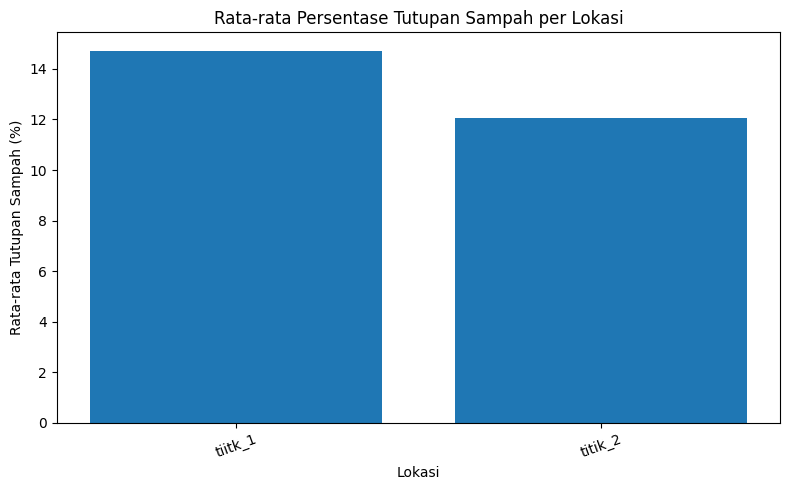

In [18]:
# Grafik Rata-rata Tutupan Sampah

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(summary["lokasi"], summary["rata_rata_tutupan"])
plt.xlabel("Lokasi")
plt.ylabel("Rata-rata Tutupan Sampah (%)")
plt.title("Rata-rata Persentase Tutupan Sampah per Lokasi")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/content/hasil_segmentasi/grafik_rata_rata_tutupan.png", dpi=300)
plt.show()

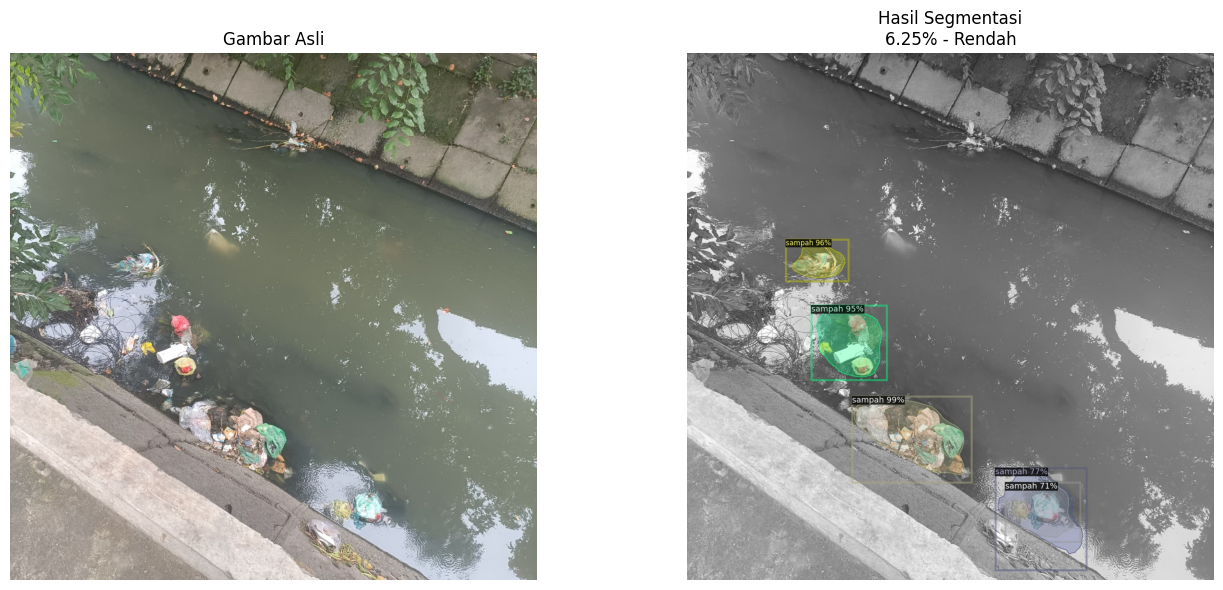

In [19]:
# Tampilkan Gambar Asli vs Hasil Segmentasi

import matplotlib.pyplot as plt
import cv2
import os

sample_row = df_results.sample(1).iloc[0]

lokasi = sample_row["lokasi"]
nama_gambar = sample_row["gambar"]

original_path = os.path.join(TESTING_ROOT, lokasi, nama_gambar)
segmented_path = sample_row["path_hasil_segmentasi"]

img_original = cv2.cvtColor(cv2.imread(original_path), cv2.COLOR_BGR2RGB)
img_segmented = cv2.cvtColor(cv2.imread(segmented_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_segmented)
plt.title(
    f"Hasil Segmentasi\n"
    f"{sample_row['persentase_tutupan_sampah']}% - "
    f"{sample_row['kategori_pencemaran_visual']}"
)
plt.axis("off")

plt.tight_layout()
plt.savefig("/content/hasil_segmentasi/contoh_asli_vs_segmentasi.png", dpi=300)
plt.show()

In [20]:
# Download Semua Hasil

!zip -r /content/hasil_segmentasi.zip /content/hasil_segmentasi

from google.colab import files
files.download("/content/hasil_segmentasi.zip")

  adding: content/hasil_segmentasi/ (stored 0%)
  adding: content/hasil_segmentasi/titik_2/ (stored 0%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_001.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_004.jpeg (deflated 2%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_007.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_005.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_008.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_002.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_006.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/titik_2/hasil_B_test_003.jpeg (deflated 1%)
  adding: content/hasil_segmentasi/grafik_rata_rata_tutupan.png (deflated 28%)
  adding: content/hasil_segmentasi/hasil_pengujian.csv (deflated 77%)
  adding: content/hasil_segmentasi/contoh_asli_vs_segmentasi.png (deflated 1%)
  adding: content/hasil_segmentasi/r

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>